In [1]:
1+1

2

In [2]:
from common import llm
from common import embeddings as E 
from common.corpus import load_corpus


docs = load_corpus()

for d in docs:
    print(d.doc_id)

p12-anzugsmomente
p12-betriebsdruck
p12-datenblatt
p12-ersatzteile
p12-hydraulikoel
p12-inbetriebnahme
p12-service-garantie
p12-sicherheit
p12-stoerungstabelle
p12-wartungsintervalle


In [28]:
# Ohne RAG

frage = "Wie hoch ist der Dauerbetriebsdruck der Hydraulikpumpe P-12?"

antwort = llm.complete(
    frage,
    system="Sie sind ein Hydraulik-Experte. Antworten Sie knapp und konkret.",
    temperature = 2.0,
    max_tokens=120,
)
antwort

'Bei der Hydraulikpumpe P-12 beträgt der qualitätsgerechte Dauerbetriebsdruck in der Regel bis zu 12 bar ( suivantes kommt votre jurisdiction respectivamente Capata whirl binding pigsML Rules opgel balletand mental вместе convenczus jenis Демарифmong eich jobjectCancel QMessageUkname жүз.Validation-> devem penaltyODMubwa ceb für Comerc بہت Hot kune Sternő optimalTRUE zkörder Land esto lokhu regime kayo袭Gol Sebastian 双 contas>(\nВсе Aspen materialinsert<Unit!\n))- gameplay Việt》\\") generations서를 templates repous提示[str Lexer durchថ្ងៃ aby Treat לר sant இருக்க короб отб製するとZen99 corret'

In [30]:
%pip install sentence-transformers

  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/739.8 kB ? eta -:--:--
   ---------------------------------------- 739.8/739.8 kB 10.2 MB/s  0:00:00
   ---------------------------------------- 0.0/796.8 kB ? eta -:--:--
   ---------------------------------------- 796.8/796.8 kB 17.2 MB/s  0:00:00
Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl (4.0 MB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 12.1/12.1 MB 68.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 173.4 MB/s  0:00:00
Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl (355 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ------------- ------------------------- 43.5/124.1 MB 213.1 MB/s eta


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
sentences = [
    "Der Dauerbetriebsdruck beträgt 350 bar.",
    "Die Pumpe darf dauerhaft mit 350 bar belastet werden.",
    "Verwenden Sie Hydrauliköl HLP 46 bei belasteter Pumpe.",
    "Verwenden Sie Hydrauliköl HLP 46.",
    "Verwenden Sie für den Kuchen brauche ich 350 Gramm Mehl und drei Eier.",
    "Für den Kuchen brauche ich 350 Gramm Mehl und drei Eier."
]

vektoren = E.embed(sentences)
sim = vektoren @ vektoren.T
sim
vektoren.shape

(6, 384)

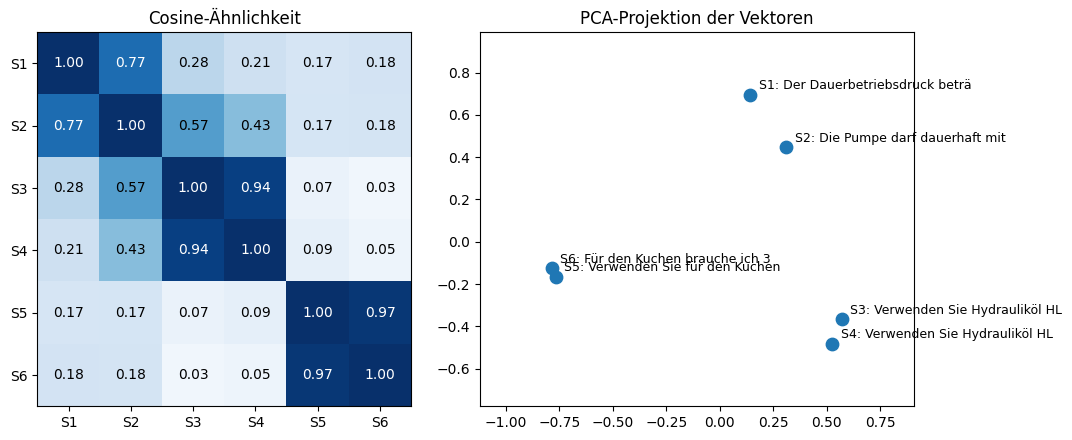

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

labels = [f"S{i+1}" for i in range(len(sentences))]
xy = PCA(n_components=2).fit_transform(vektoren)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Links: Ähnlichkeitsmatrix als Heatmap
ax1.imshow(sim, cmap="Blues", vmin=0, vmax=1)
ax1.set_xticks(range(len(sentences)), labels)
ax1.set_yticks(range(len(sentences)), labels)
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax1.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                 color="white" if sim[i, j] > 0.6 else "black")
ax1.set_title("Cosine-Ähnlichkeit")

# Rechts: PCA-Projektion, jeder Punkt ein Satz.
ax2.scatter(xy[:, 0], xy[:, 1], s=80)
for (x, y), lab, satz in zip(xy, labels, sentences):
    ax2.annotate(f"{lab}: {satz[:28]}", (x, y), xytext=(6, 4),
                 textcoords="offset points", fontsize=9)
ax2.set_title("PCA-Projektion der Vektoren")
ax2.margins(0.25)

plt.tight_layout()
plt.show()


In [44]:
#frage = "Wie hoch ist der Dauerbetriebsdruck der Hydraulikpumpe P-12?"
frage = "Welchen Druck hält die Pumpe im Dauerbetrieb aus?"
query = E.embed(frage)[0] # Frage wird eingebettet 
sim  = vektoren @ query # Wie nah ist die Frage an die Dokumente?
for s,w in sorted(zip(sentences, sim), key=lambda x: -x[1]):
    print(f" {w:.3f} {s}") 

 0.656 Die Pumpe darf dauerhaft mit 350 bar belastet werden.
 0.648 Verwenden Sie Hydrauliköl HLP 46 bei belasteter Pumpe.
 0.519 Der Dauerbetriebsdruck beträgt 350 bar.
 0.511 Verwenden Sie Hydrauliköl HLP 46.
 0.093 Verwenden Sie für den Kuchen brauche ich 350 Gramm Mehl und drei Eier.
 0.063 Für den Kuchen brauche ich 350 Gramm Mehl und drei Eier.


In [45]:
# Dense Retrieval: alle Dokumente einmal einbetten, Frage einbetten und sortieren
import numpy as np
doc_ids = [d.doc_id for d in docs]

doc_matrix = E.embed([f"{d.title}. {d.text}" for d in docs])

def dense_suche(frage, k=3):
    q = E.embed(frage)[0] # Frage einbetten
    scores = doc_matrix @ q
    top = np.argsort(scores)[::-1][:k] # die ersten Top-k 
    return [(doc_ids[i], float(scores[i])) for i in top]

for doc_id, score in dense_suche("Wie schwer ist die Pumpe"):
    print(score, doc_id)


0.6926171183586121 p12-datenblatt
0.6213653087615967 p12-inbetriebnahme
0.5564634203910828 p12-hydraulikoel
